# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 08     |  |
| :-------------|:-------------|
| Sybren Kuijlaars | 6540414 |
| Alesja Zorina| 6575129|
| Daan d'Engelbronner| 6537812 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Sybren', 'Alesja','Daan']

## Opdracht 1: Planning.

| Planning Groep: XX     |Tijdstip / Tijdspanne  |
|---|---|
| Kalibratie | voor 11:30 |
| testen meetopstelling | voor 12:00 |
| groep aanwezig 1| 11:00-12:30 |
| groep aanwezig 2| 13:30-17:30 |
| Pauze 1| 12:30-13:30 |
| Pauze 2| ong 14:30-15:00 |

## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

### kalibratie-opstelling groep 08
<img src="Calibreer_opstelling.jpeg" width="400">

[0.03444092 0.73670131]


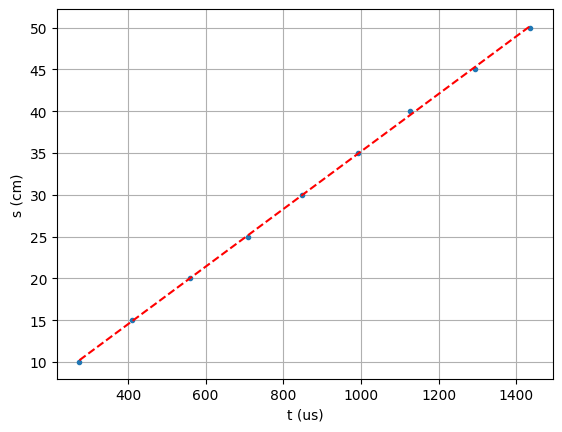

In [3]:
from scipy.optimize import curve_fit

arduino_meting = np.array([275,410,560,708,848,991,1126,1293,1436])
afstand = np.array([10,15,20,25,30,35,40,45,50])

def Afstand(x,a,b):
    return a*x + b

var, cov = curve_fit(Afstand,arduino_meting,afstand)

x_fit = np.linspace(np.min(arduino_meting),np.max(arduino_meting),10000)
y_fit = Afstand(x_fit,*var)

print(var)

plt.figure()
plt.plot(arduino_meting, afstand, ".")
plt.plot(x_fit,y_fit,'r--')
plt.xlabel("t (us)")
plt.ylabel("s (cm)")
plt.grid(True)
plt.show()

## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  40   0  30  44.50
1   0  30   0  20  44.50
2  40   0  30   0  47.46
3  30   0  20   0  45.30


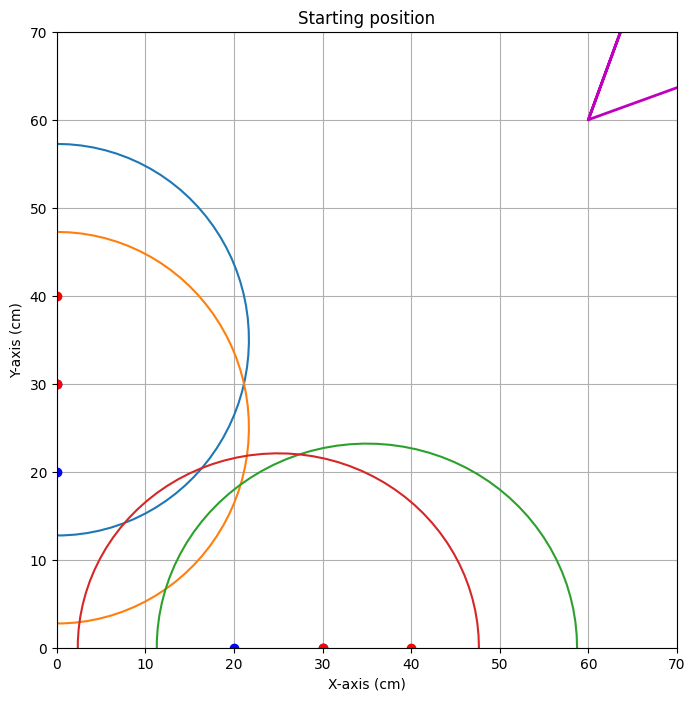


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=96.515


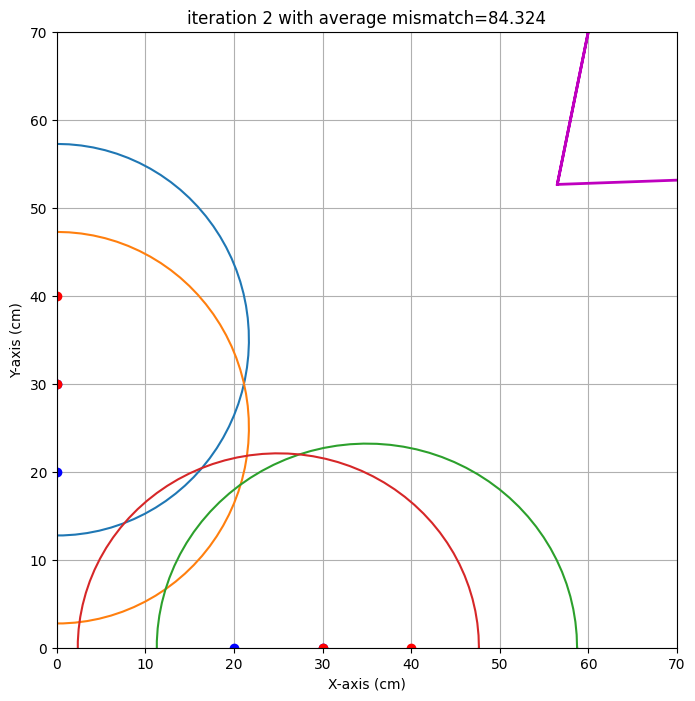

end iteration 2 with average mismatch=84.324


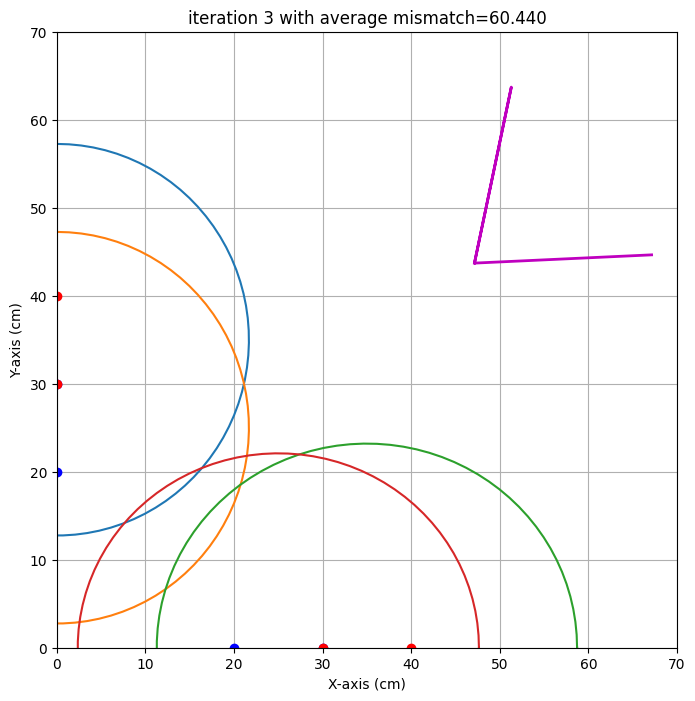

end iteration 3 with average mismatch=60.440


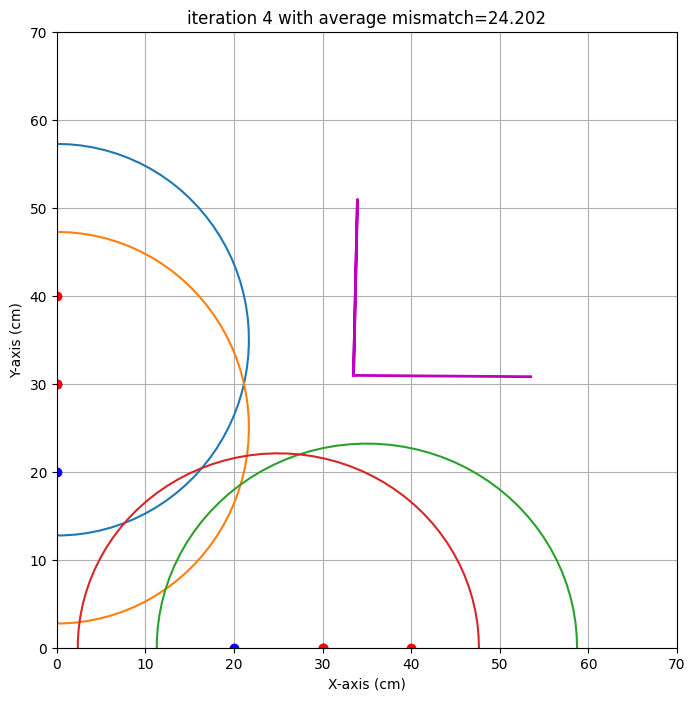

end iteration 4 with average mismatch=24.202


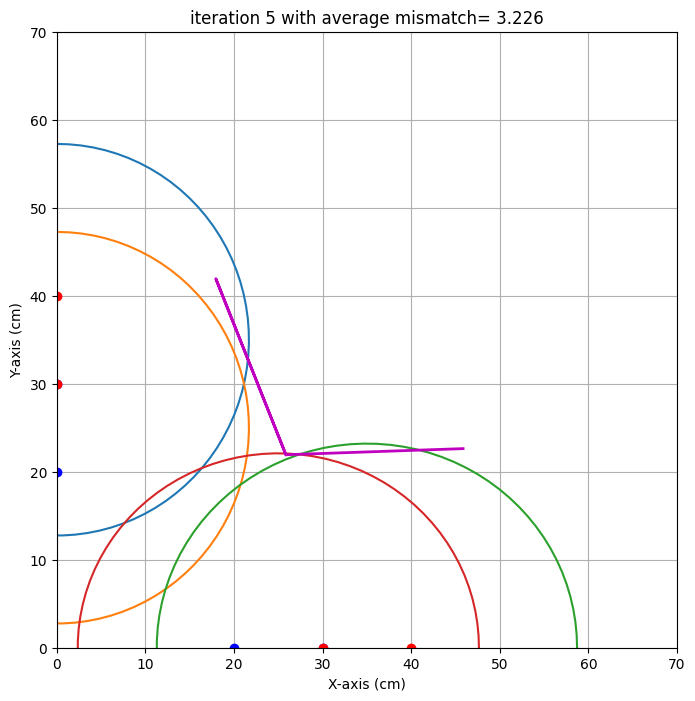

end iteration 5 with average mismatch= 3.226


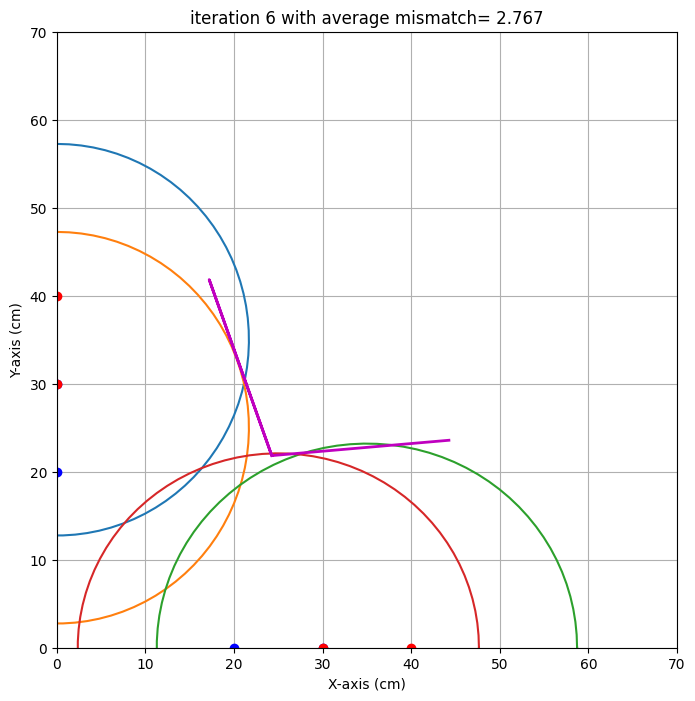

end iteration 6 with average mismatch= 2.767


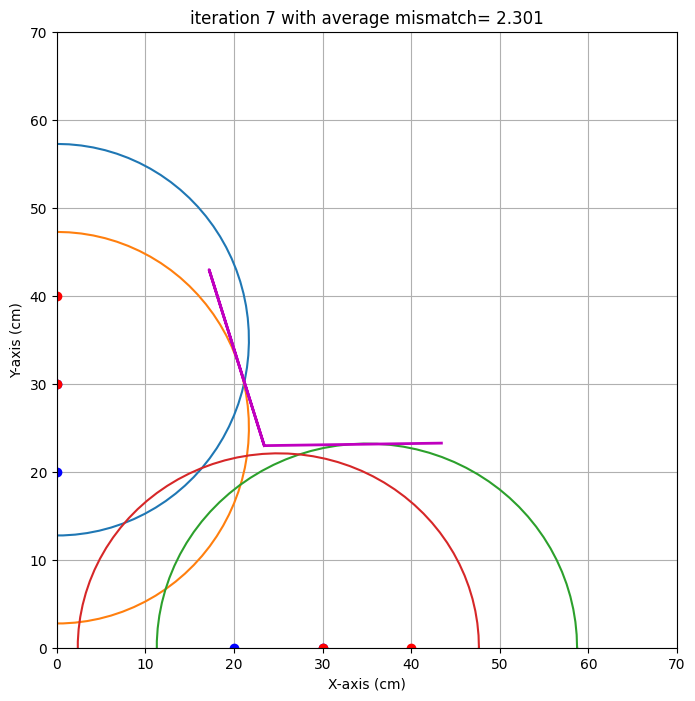

end iteration 7 with average mismatch= 2.301


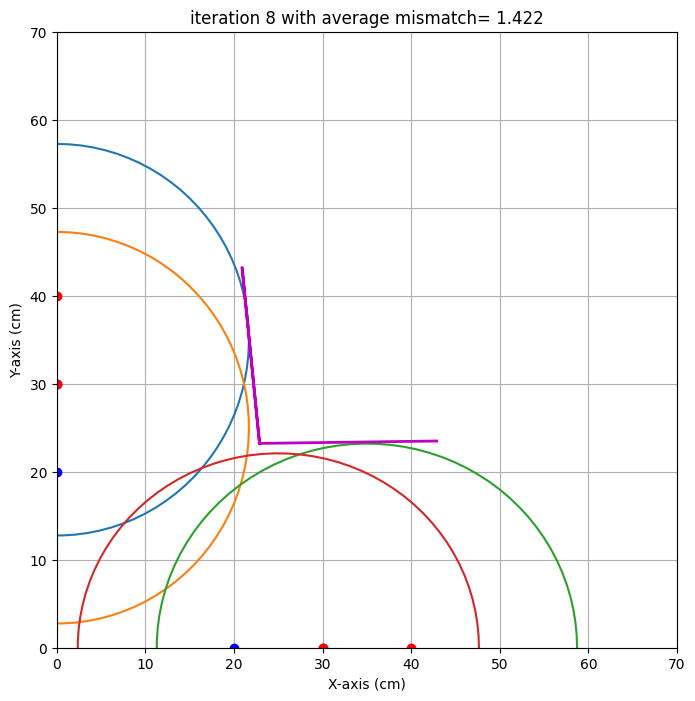

end iteration 8 with average mismatch= 1.422


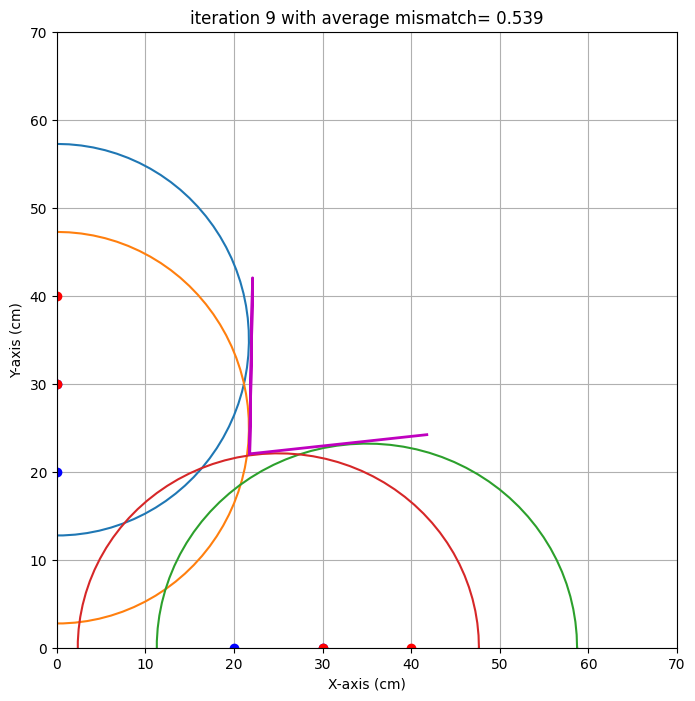

end iteration 9 with average mismatch= 0.539


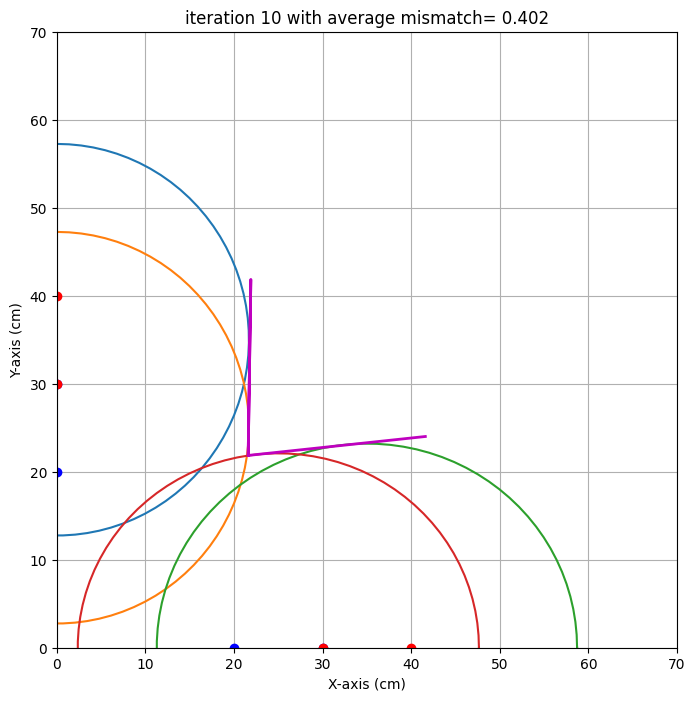

end iteration 10 with average mismatch= 0.402
end iteration 11 with average mismatch= 0.400


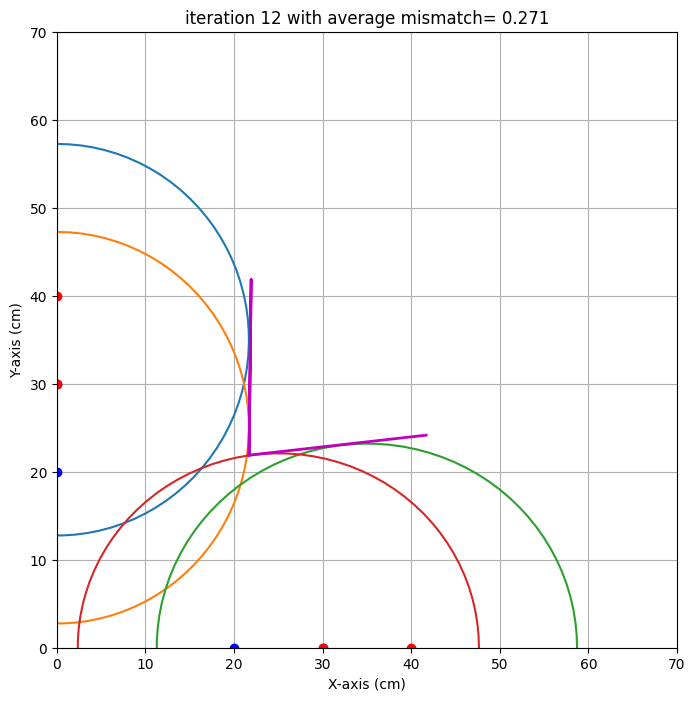

end iteration 12 with average mismatch= 0.271


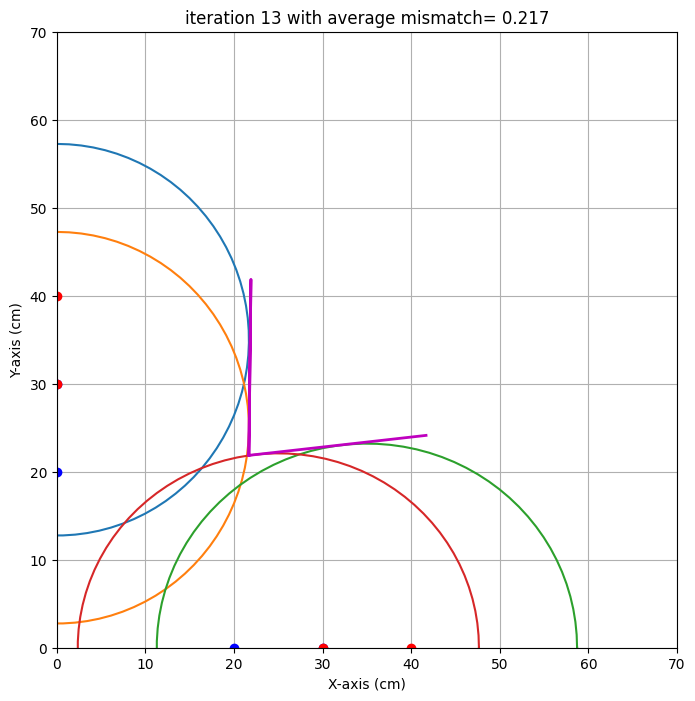

end iteration 13 with average mismatch= 0.217


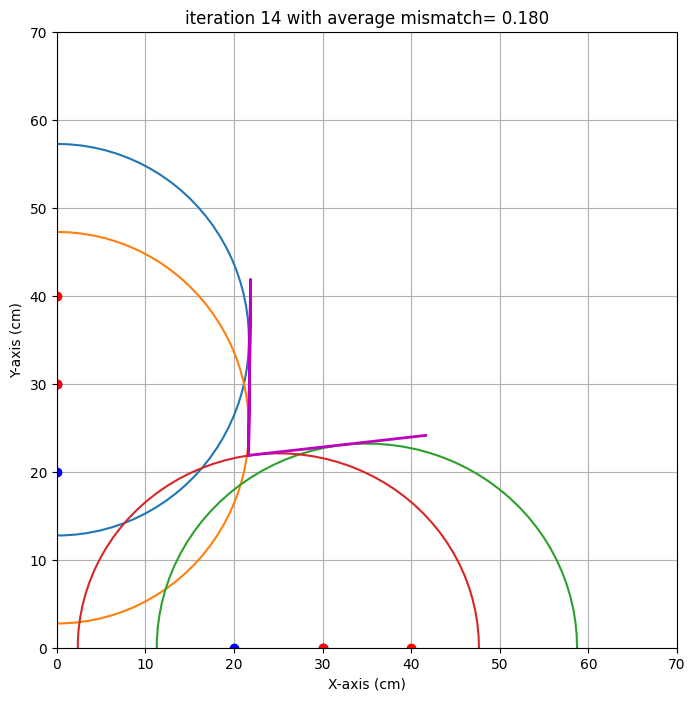

end iteration 14 with average mismatch= 0.180
end iteration 15 with average mismatch= 0.180
end iteration 16 with average mismatch= 0.179
end iteration 17 with average mismatch= 0.179
end iteration 18 with average mismatch= 0.179
end iteration 19 with average mismatch= 0.179
end iteration 20 with average mismatch= 0.179
end iteration 21 with average mismatch= 0.179


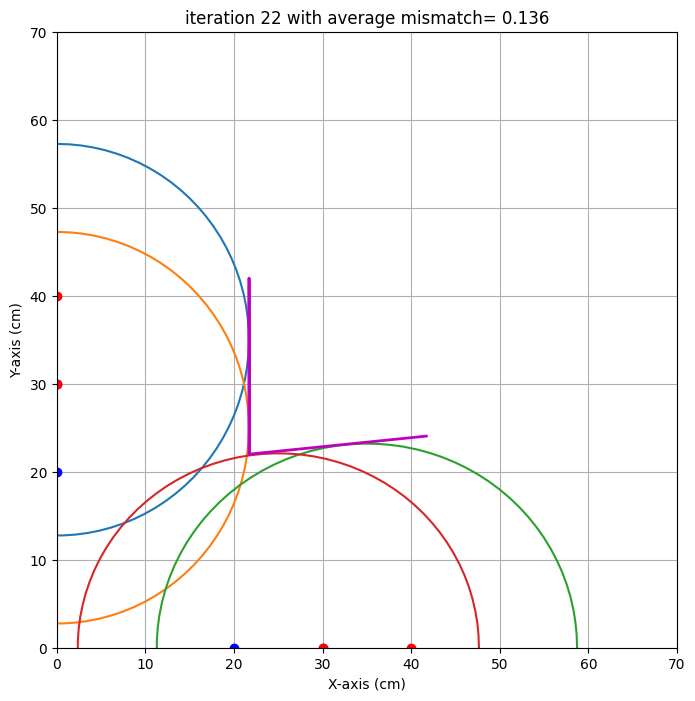

end iteration 22 with average mismatch= 0.136


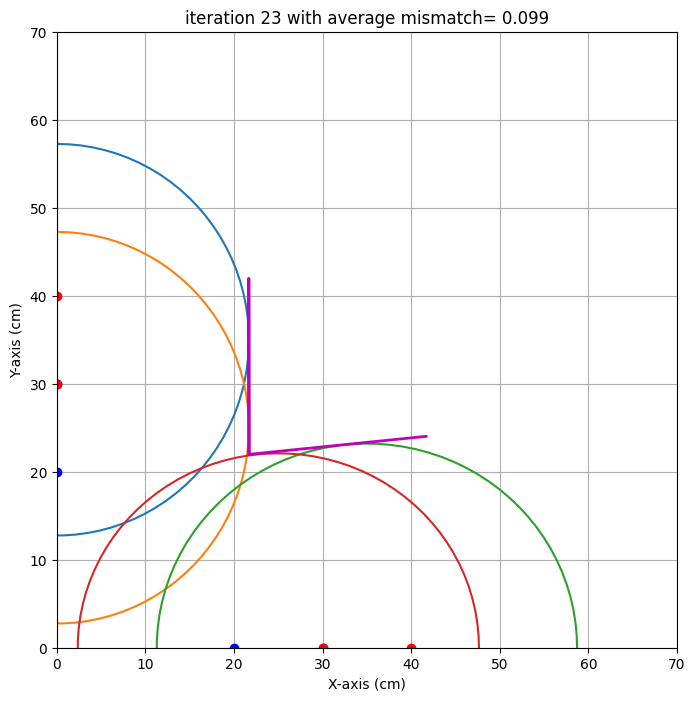

end iteration 23 with average mismatch= 0.099
end iteration 24 with average mismatch= 0.095
end iteration 25 with average mismatch= 0.095
end iteration 26 with average mismatch= 0.095
end iteration 27 with average mismatch= 0.095
end iteration 28 with average mismatch= 0.095
end iteration 29 with average mismatch= 0.095
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.095
###############################################################################
end of iteration  30
Best alpha=   5.84 with uncertainty=   0.41
Best beta =  -0.05 with uncertainty=   0.10
Best x0   =  21.68 with uncertainty=   0.07
Best y0   =  21.97 with uncertainty=   0.18
###############################################################################


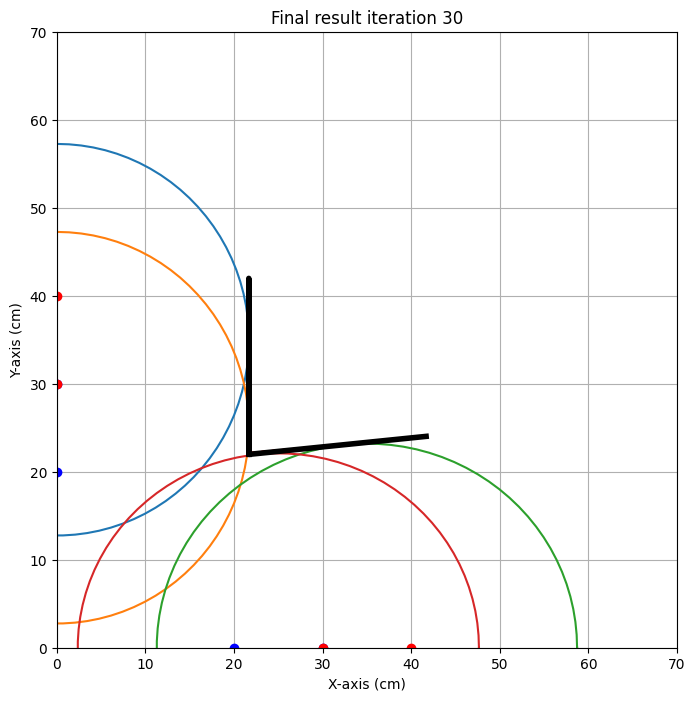

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

# Zeven metingen gedaan, maar 3 waren ongeldig ((0,10),(0,20)) en ((10,0),(20,0)) en ((10,0),(0,10))
Test_meting = np.array([44.50,44.50,47.46,45.30])

dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,Test_meting[0]],
    [0,30,0,20,Test_meting[1]],
    #[0,10,0,20,Test_meting[2]],
    [40,0,30,0,Test_meting[2]],
    [30,0,20,0,Test_meting[3]]
    #[10,0,20,0,Test_meting[4]],
    #[10,0,0,10,Test_meting[5]]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 21.7 cm met een standaardafwijking van 0.1 cm 
y0: 22.0 cm met een standaardafwijking van 0.2 cm 
alpha: 5.8 graden met een standaardafwijking van 0.4 graad 
beta: -0.1 graden met een standaardafwijking van 0.1 graad 



## Opdracht 5: Iteratie 0

#### algoritme Sybren
<img src="Algoritme_Sybren.jpeg" width="400">

#### algoritme Alesja
<img src="Algoritme_Alesja.jpeg" width="400">

#### algoritme Daan
<img src="Algoritme_Daan.jpeg" width="400">

Tijdens het testen van de algoritmes is gebruik gemaakt van een object met x0 = 29, y0 = 36, alpha = 0 en  beta = 0

## Opdracht 6: Test iteratie 0.

In [17]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0':29,  #zelf aanvullen,
           'y0':36, #zelf aanvullen,
           'alpha' :1, #zelf aanvullen,
           'beta' :1 #zelf aanvullen},
          }
           
Algoritme_Alesja = np.array([80.16,80.12,63.59,61.80])
Algoritme_Daan = np.array([84.29,78.30,79.64,56.72,56.93,56.36])
# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Alesja' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
         [40,0,55,0,Algoritme_Alesja[0]],
         [30,0,45,0,Algoritme_Alesja[1]],
         [0,30,0,45,Algoritme_Alesja[2]],
         [0,40,0,55,Algoritme_Alesja[3]]
         ]),
      'Daan' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
        [30,0,20,0,Algoritme_Daan[0]],
        [40,0,30,0,Algoritme_Daan[1]],
        #[25,0,15,0,Algoritme_Daan[2]], #fout
        [45,0,35,0,Algoritme_Daan[2]],
        #[0,30,0,20,Algoritme_Daan[3]], #fout
        [0,50,0,40,Algoritme_Daan[3]],
        [0,60,0,50,Algoritme_Daan[4]],
        [0,65,0,55,Algoritme_Daan[5]]
         ])
      }

## Opdracht 7: Evaluatie.

Alesja
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  40   0  55   0  80.16
1  30   0  45   0  80.12
2   0  30   0  45  63.59
3   0  40   0  55  61.80


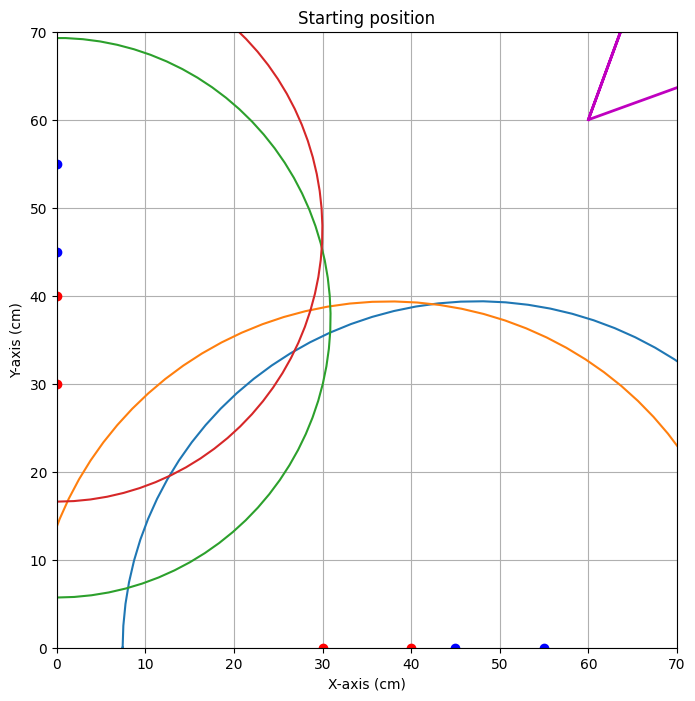


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=61.359


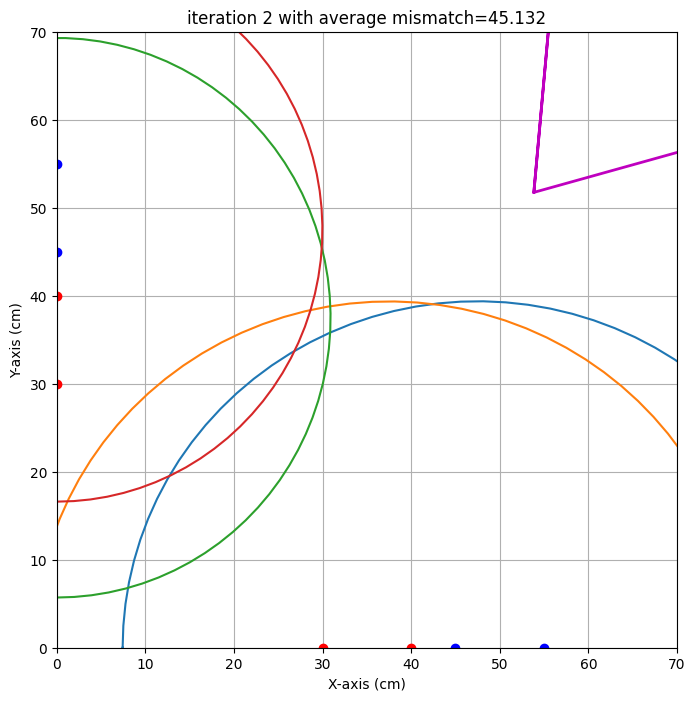

end iteration 2 with average mismatch=45.132


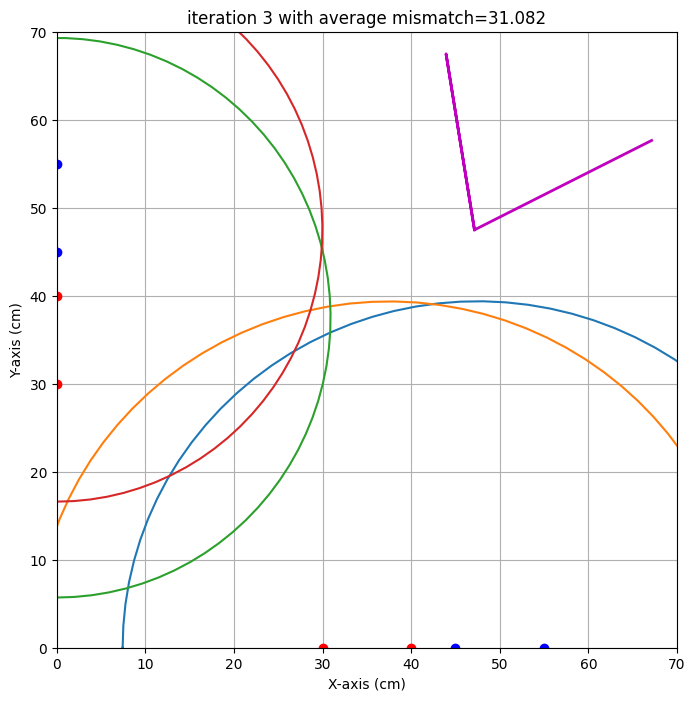

end iteration 3 with average mismatch=31.082


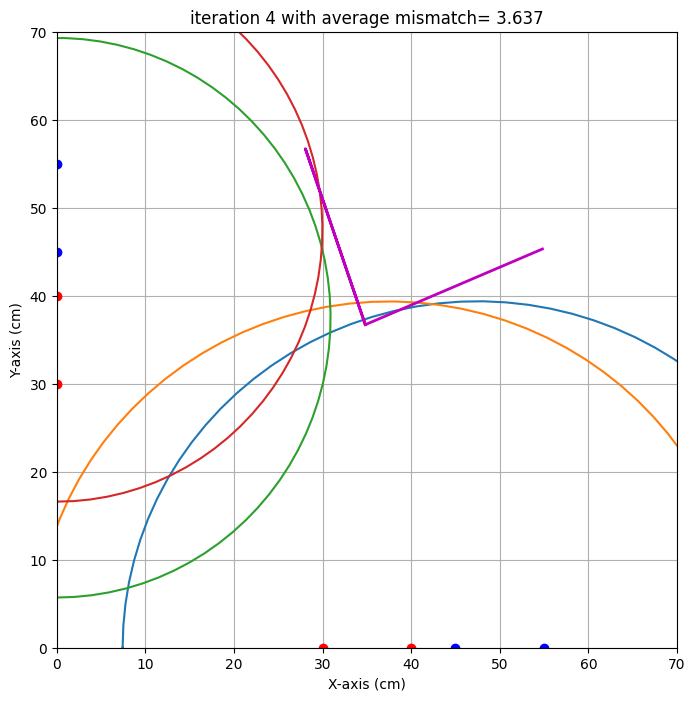

end iteration 4 with average mismatch= 3.637


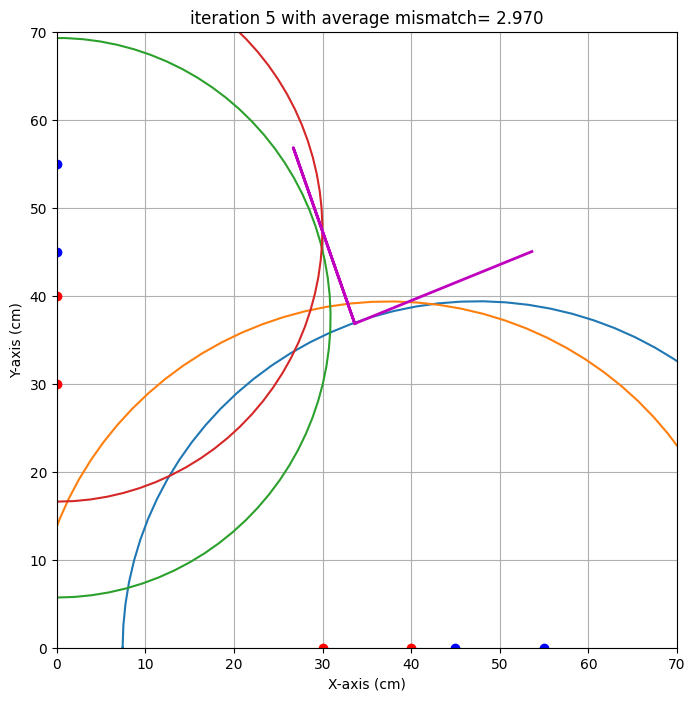

end iteration 5 with average mismatch= 2.970


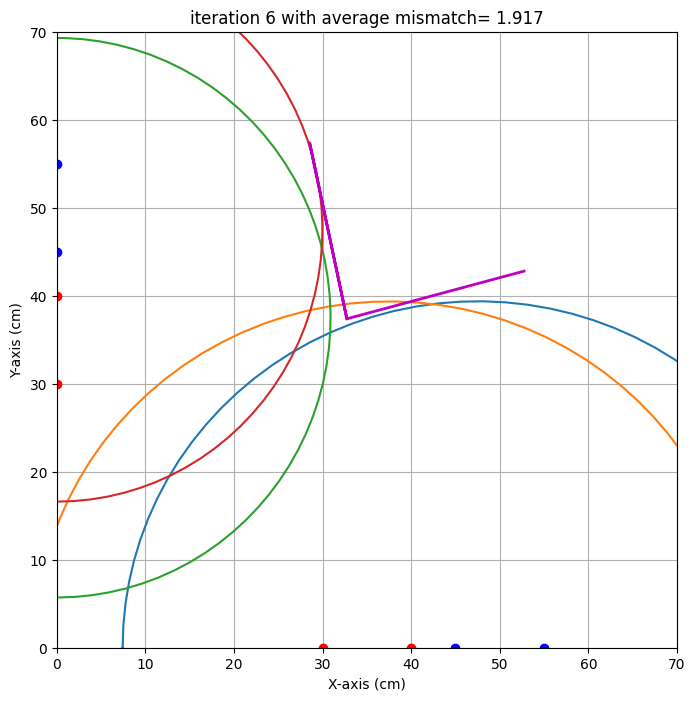

end iteration 6 with average mismatch= 1.917


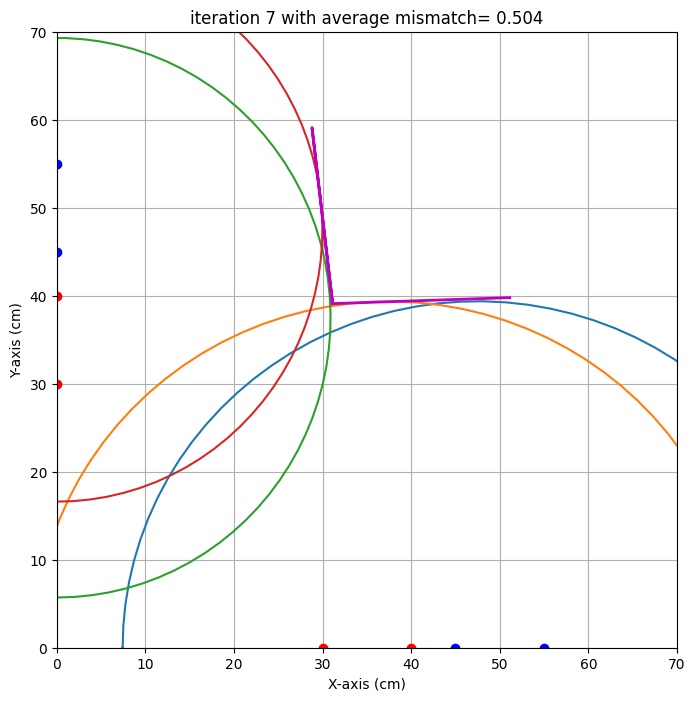

end iteration 7 with average mismatch= 0.504


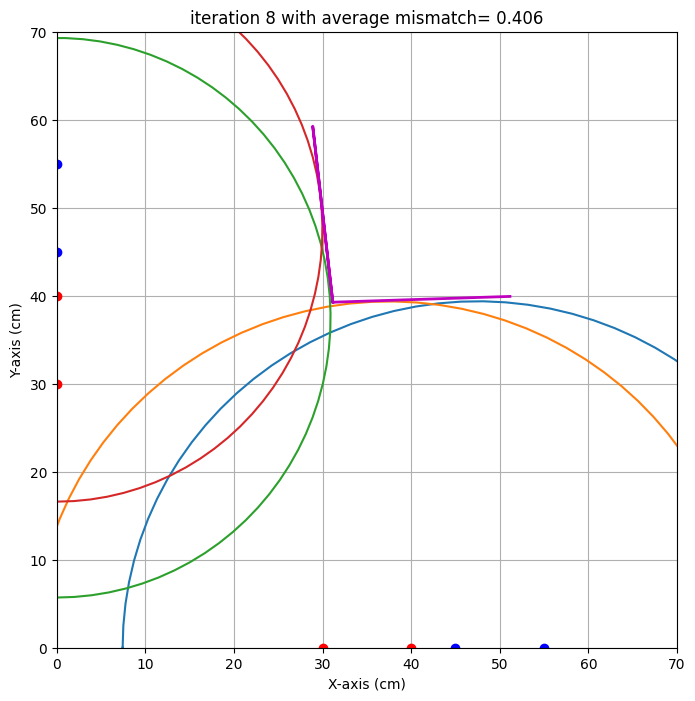

end iteration 8 with average mismatch= 0.406


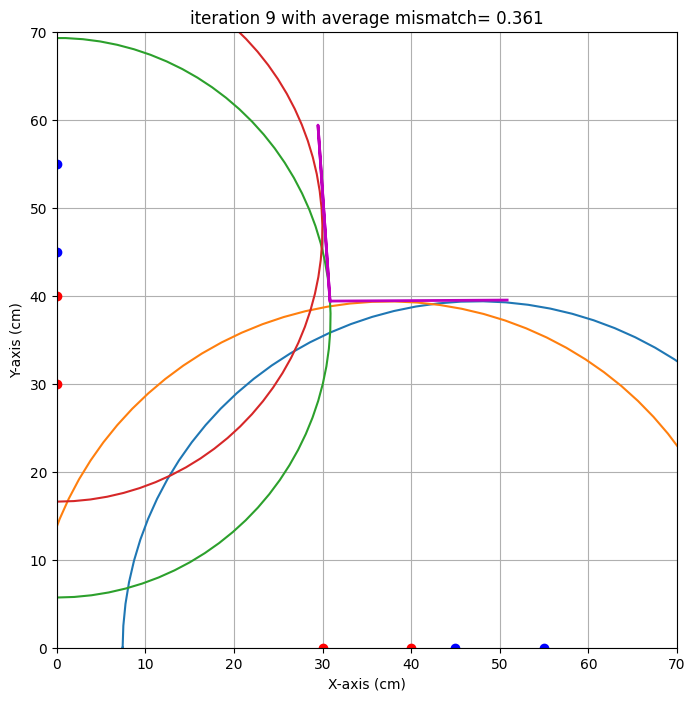

end iteration 9 with average mismatch= 0.361
end iteration 10 with average mismatch= 0.353
end iteration 11 with average mismatch= 0.319


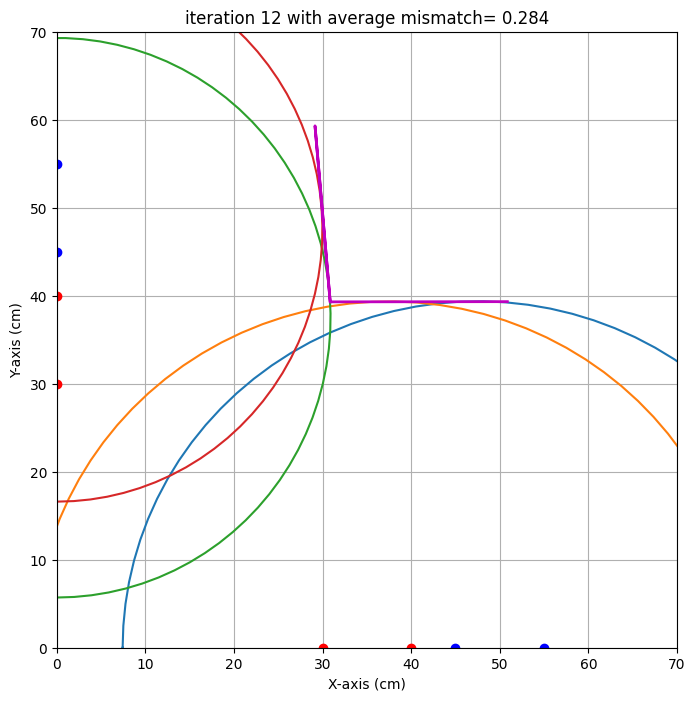

end iteration 12 with average mismatch= 0.284


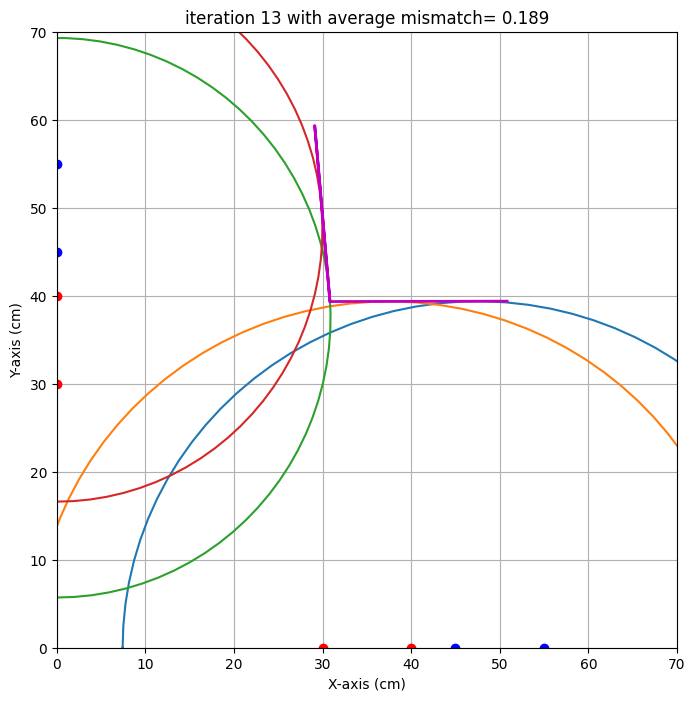

end iteration 13 with average mismatch= 0.189
end iteration 14 with average mismatch= 0.185
end iteration 15 with average mismatch= 0.184
end iteration 16 with average mismatch= 0.184
end iteration 17 with average mismatch= 0.184
end iteration 18 with average mismatch= 0.184
end iteration 19 with average mismatch= 0.184
end iteration 20 with average mismatch= 0.184
end iteration 21 with average mismatch= 0.184
end iteration 22 with average mismatch= 0.184
end iteration 23 with average mismatch= 0.184
end iteration 24 with average mismatch= 0.184
end iteration 25 with average mismatch= 0.184
end iteration 26 with average mismatch= 0.184
end iteration 27 with average mismatch= 0.184
end iteration 28 with average mismatch= 0.184
end iteration 29 with average mismatch= 0.184
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.184
#############

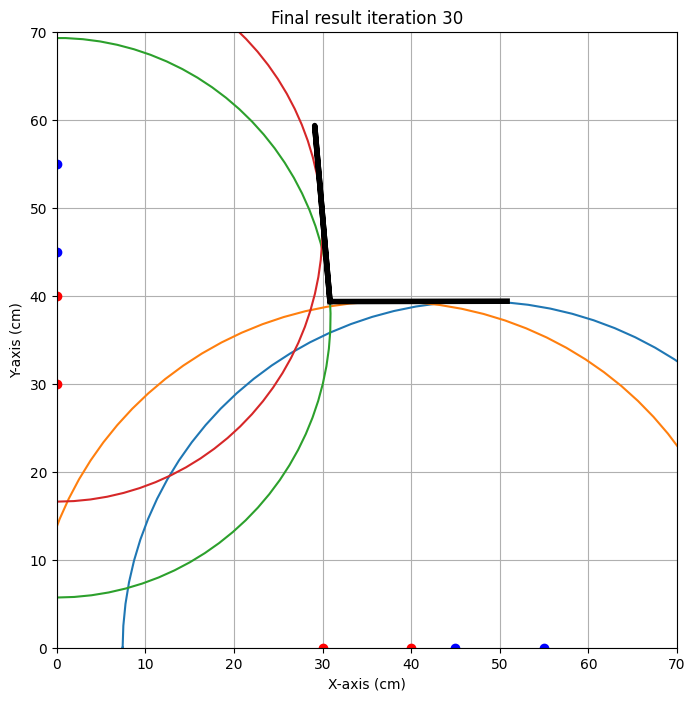

{'alpha': np.float64(0.11670783028269383), 'alpha_eps': 0.0, 'beta': np.float64(-4.927887660185121), 'beta_eps': 0.0, 'x0': np.float64(30.830361380874024), 'x0_eps': 0.0, 'y0': np.float64(39.33589384424804), 'y0_eps': 0.0}
Daan
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  30   0  20   0  84.29
1  40   0  30   0  78.30
2  45   0  35   0  79.64
3   0  50   0  40  56.72
4   0  60   0  50  56.93
5   0  65   0  55  56.36


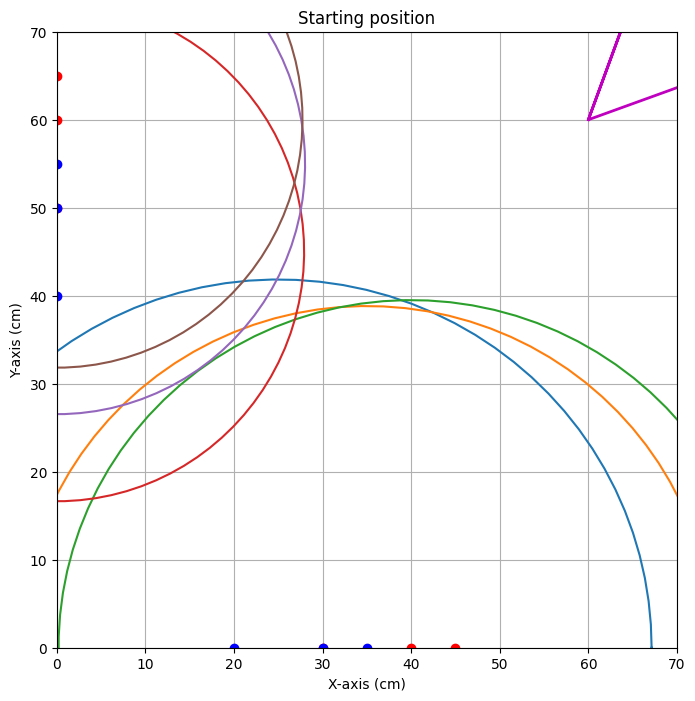


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=63.988


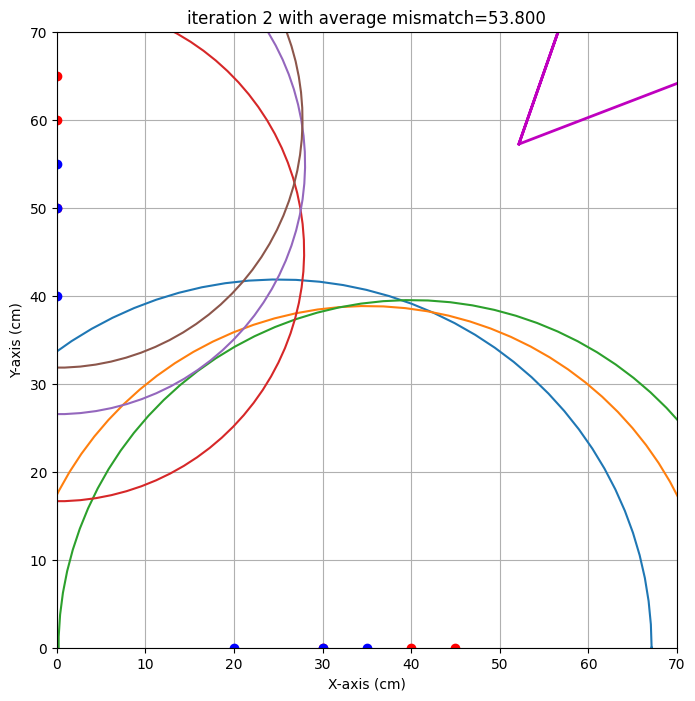

end iteration 2 with average mismatch=53.800


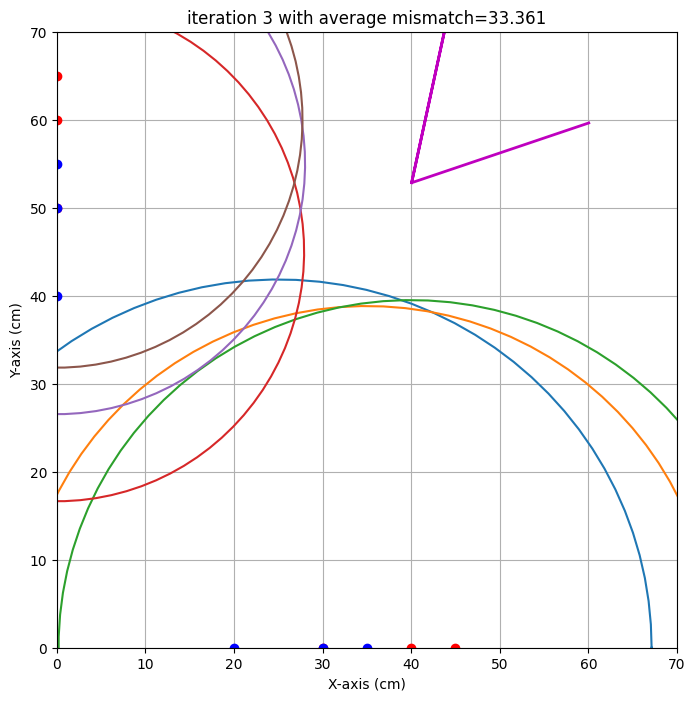

end iteration 3 with average mismatch=33.361


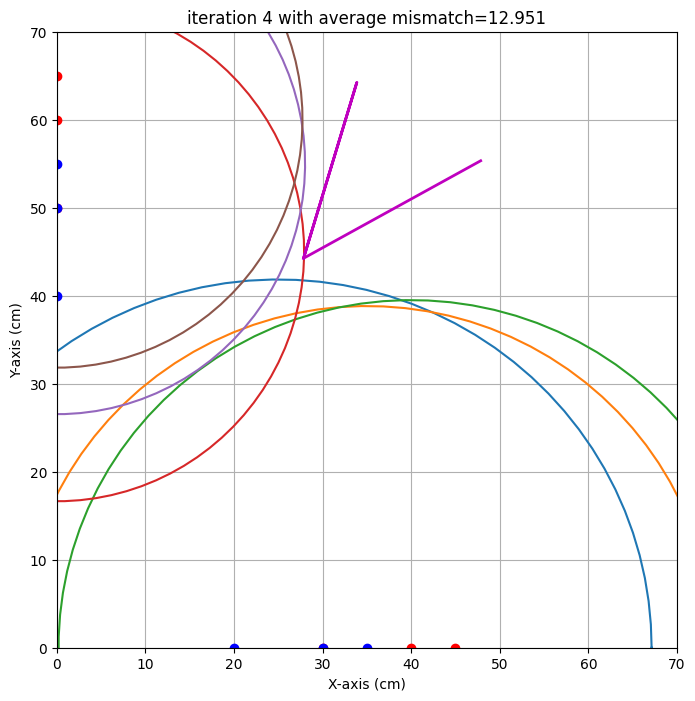

end iteration 4 with average mismatch=12.951


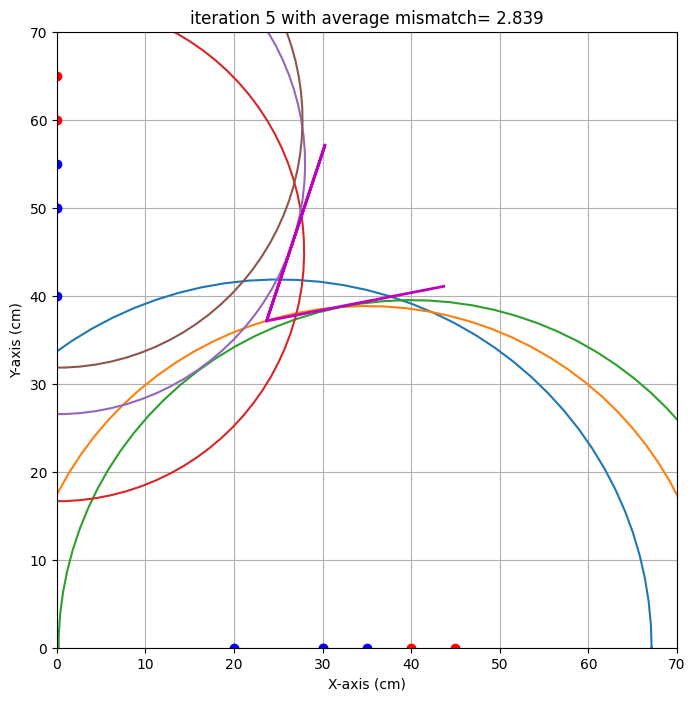

end iteration 5 with average mismatch= 2.839
end iteration 6 with average mismatch= 2.716


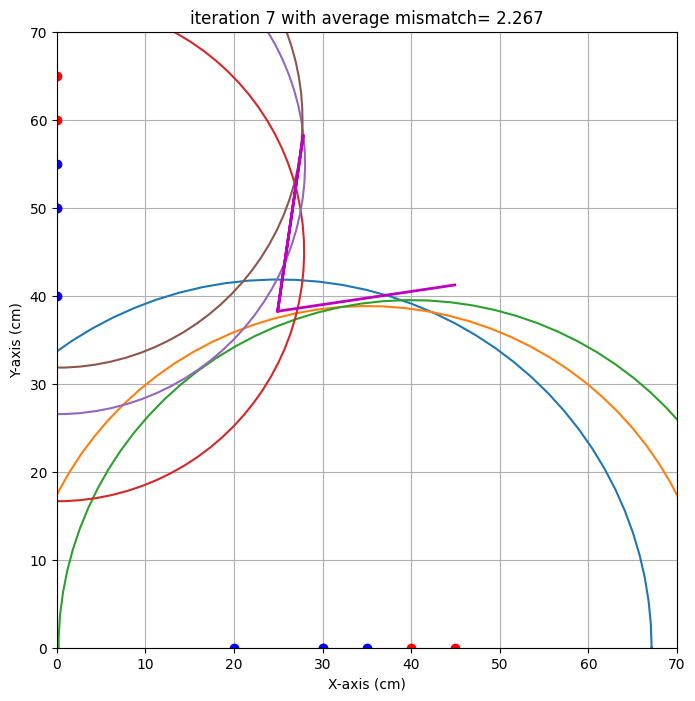

end iteration 7 with average mismatch= 2.267


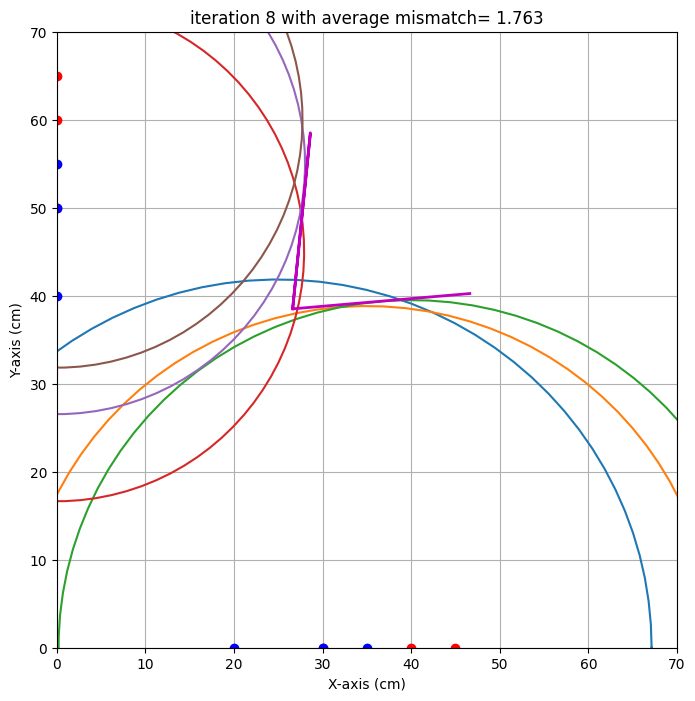

end iteration 8 with average mismatch= 1.763
end iteration 9 with average mismatch= 1.750
end iteration 10 with average mismatch= 1.745
end iteration 11 with average mismatch= 1.674
end iteration 12 with average mismatch= 1.586
end iteration 13 with average mismatch= 1.584
end iteration 14 with average mismatch= 1.531
end iteration 15 with average mismatch= 1.490
end iteration 16 with average mismatch= 1.453


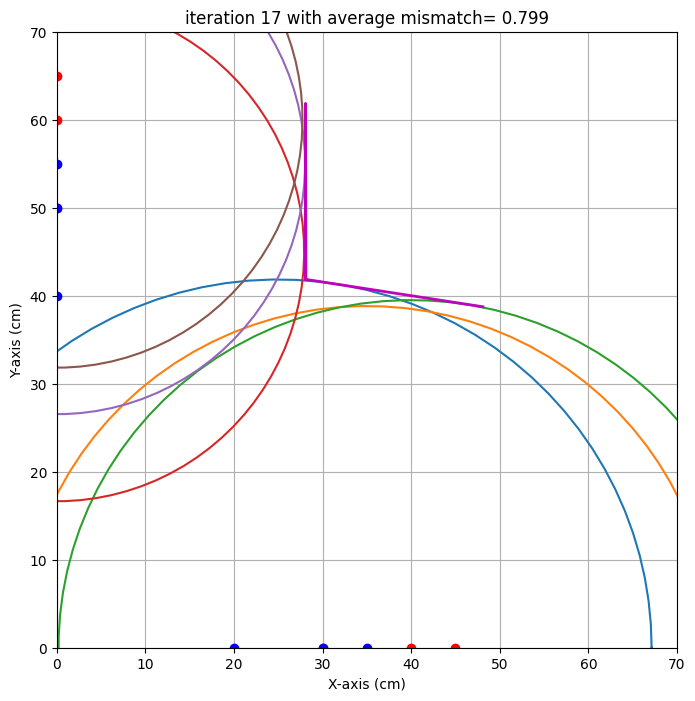

end iteration 17 with average mismatch= 0.799
end iteration 18 with average mismatch= 0.760
end iteration 19 with average mismatch= 0.757
end iteration 20 with average mismatch= 0.756
end iteration 21 with average mismatch= 0.756
end iteration 22 with average mismatch= 0.756
end iteration 23 with average mismatch= 0.756
end iteration 24 with average mismatch= 0.756
end iteration 25 with average mismatch= 0.756
end iteration 26 with average mismatch= 0.756
end iteration 27 with average mismatch= 0.756
end iteration 28 with average mismatch= 0.756
end iteration 29 with average mismatch= 0.756
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.756
###############################################################################
end of iteration  30
Best alpha=  -8.83 with uncertainty=   8.40
Best beta =  -0.09 with uncertainty=   0.33
Best x0 

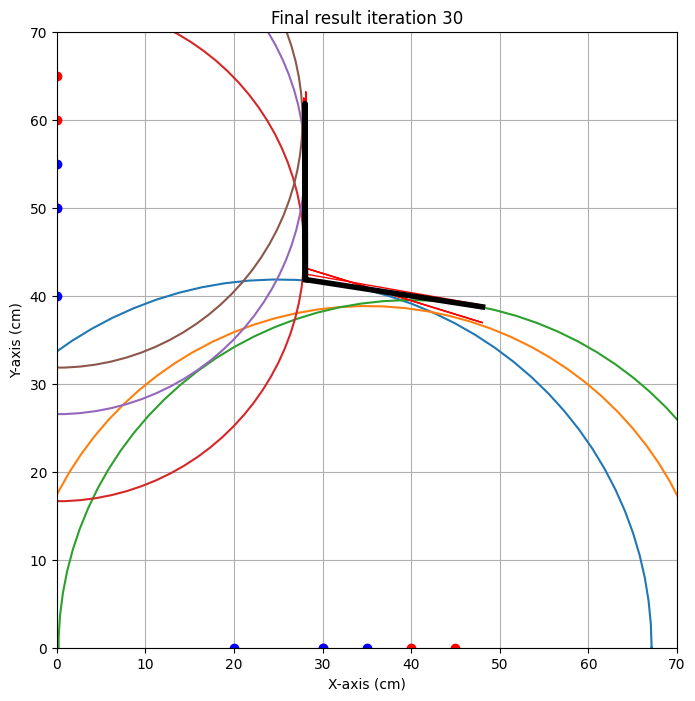

{'alpha': np.float64(-8.833086146351796), 'alpha_eps': np.float64(8.398601463746964), 'beta': np.float64(-0.0902656784334951), 'beta_eps': np.float64(0.3311417790026688), 'x0': np.float64(28.050354874685354), 'x0_eps': np.float64(0.13296812665048918), 'y0': np.float64(41.83833132415963), 'y0_eps': np.float64(1.3176908275813304)}


In [18]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

studentNames = ['Alesja','Daan'] # Sybren is hier weggehaald gezien die Algoritme niet is getest. Anders kwam er een error

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [19]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Alesja 
x0 target is : 29.0. Gevonden waarde: 30.8 cm met een standaardafwijking van 0.0 cm 
y0 target is : 36.0. Gevonden waarde: 39.3 cm met een standaardafwijking van 0.0 cm 
alpha target is : 1.0. Gevonden waarde: 0.1 graden met een standaardafwijking van 0.0 graad 
beta target is : 1.0. Gevonden waarde: -4.9 graden met een standaardafwijking van 0.0 graad 

Daan 
x0 target is : 29.0. Gevonden waarde: 28.1 cm met een standaardafwijking van 0.1 cm 
y0 target is : 36.0. Gevonden waarde: 41.8 cm met een standaardafwijking van 1.3 cm 
alpha target is : 1.0. Gevonden waarde: -8.8 graden met een standaardafwijking van 8.4 graad 
beta target is : 1.0. Gevonden waarde: -0.1 graden met een standaardafwijking van 0.3 graad 



## Opdracht 8: Iteratie1+. 14:50
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

![Alt](Verbeterd_algoritme.jpeg)


In [ ]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr       R
0  50   0  30   0   98.10
1  60   0  40   0   98.62
2  65   0  45   0  101.27
3   0  50   0  30   74.68
4   0  60   0  40   68.28
5   0  65   0  45   67.41


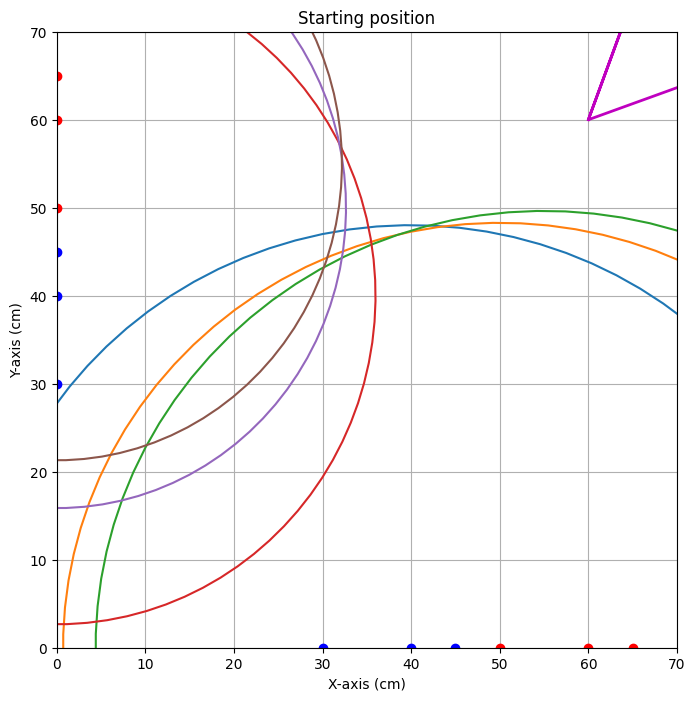


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=45.831


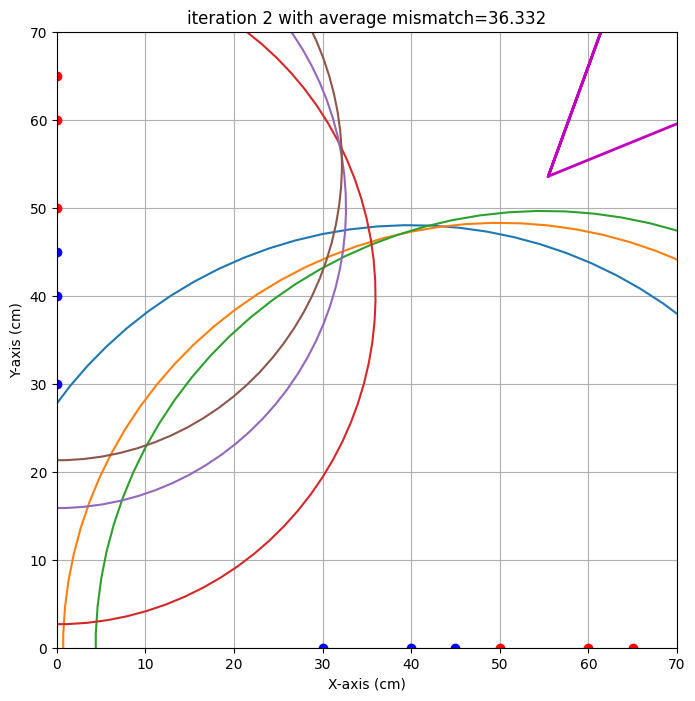

end iteration 2 with average mismatch=36.332


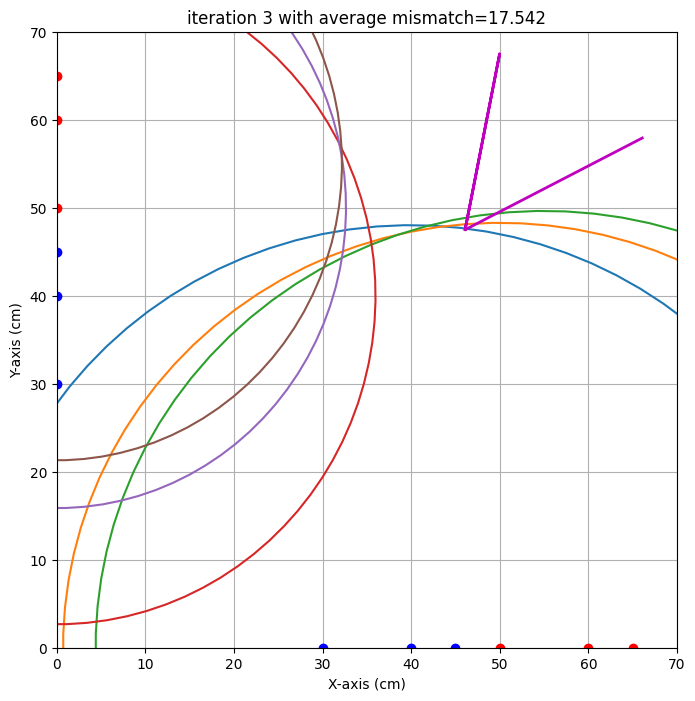

end iteration 3 with average mismatch=17.542


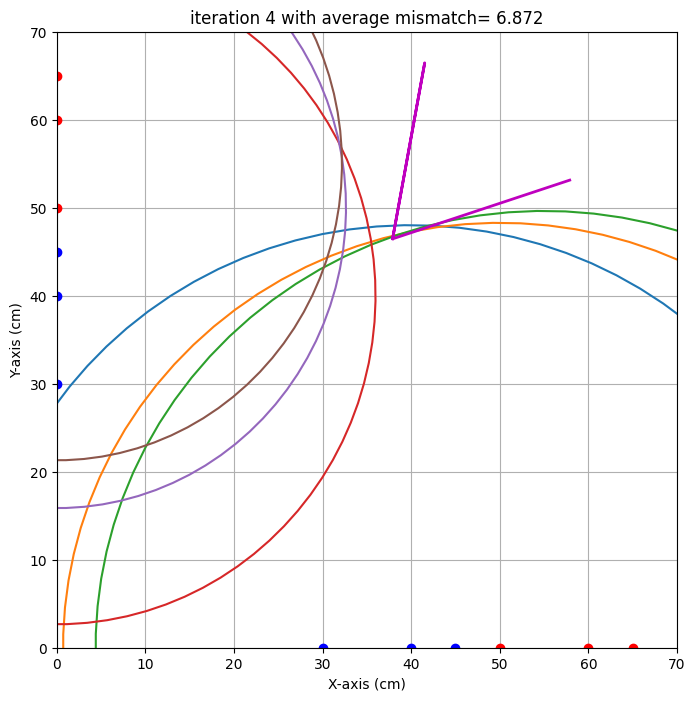

end iteration 4 with average mismatch= 6.872


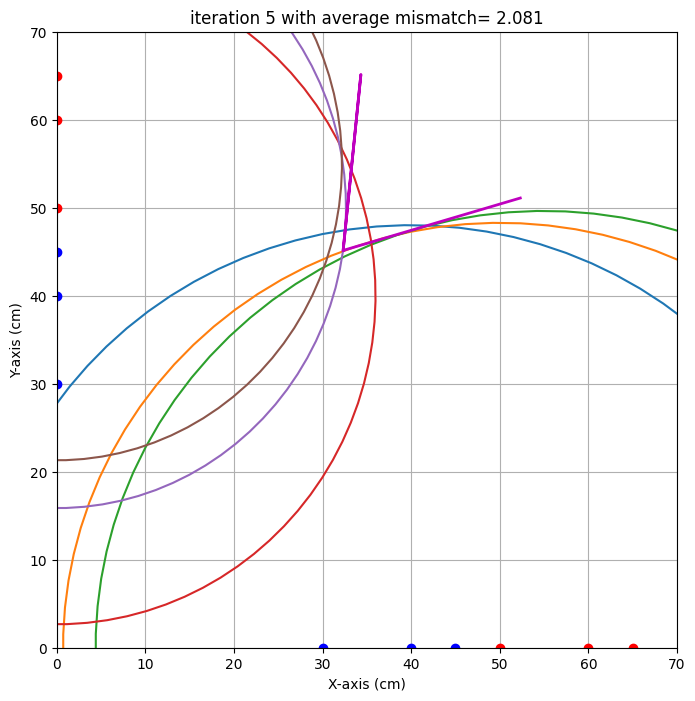

end iteration 5 with average mismatch= 2.081
end iteration 6 with average mismatch= 2.037
end iteration 7 with average mismatch= 1.998
end iteration 8 with average mismatch= 1.998
end iteration 9 with average mismatch= 1.998
end iteration 10 with average mismatch= 1.926


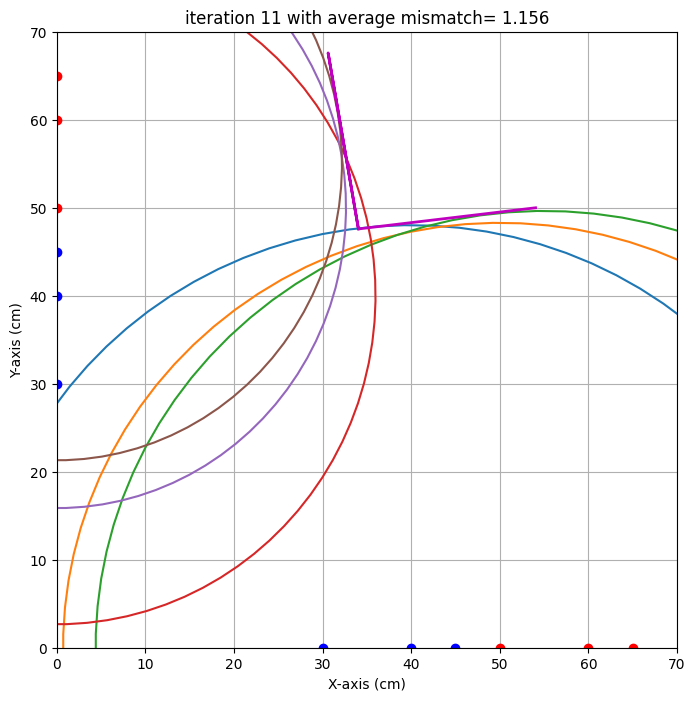

end iteration 11 with average mismatch= 1.156
end iteration 12 with average mismatch= 1.125


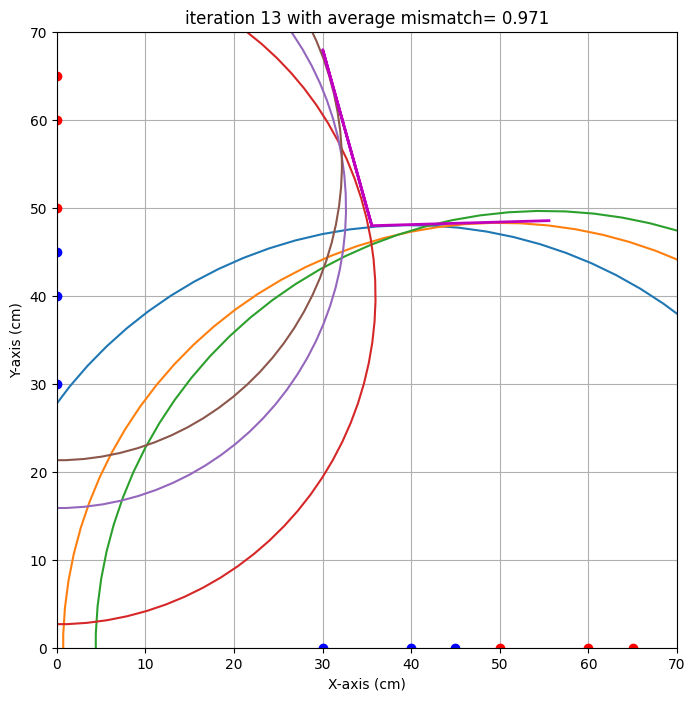

end iteration 13 with average mismatch= 0.971
end iteration 14 with average mismatch= 0.937
end iteration 15 with average mismatch= 0.878
end iteration 16 with average mismatch= 0.841
end iteration 17 with average mismatch= 0.841
end iteration 18 with average mismatch= 0.841
end iteration 19 with average mismatch= 0.841
end iteration 20 with average mismatch= 0.785
end iteration 21 with average mismatch= 0.768
end iteration 22 with average mismatch= 0.763
end iteration 23 with average mismatch= 0.763
end iteration 24 with average mismatch= 0.763
end iteration 25 with average mismatch= 0.763
end iteration 26 with average mismatch= 0.763
end iteration 27 with average mismatch= 0.763
end iteration 28 with average mismatch= 0.763
end iteration 29 with average mismatch= 0.763
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.763
###############################################################

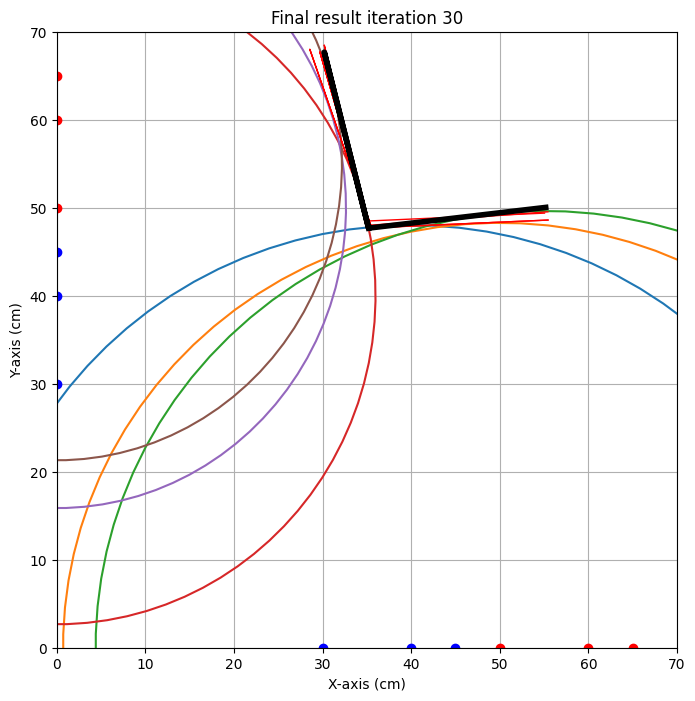

{'alpha': np.float64(6.723138348706615), 'alpha_eps': np.float64(4.188734092992388), 'beta': np.float64(-14.036506325306506), 'beta_eps': np.float64(4.952663355431325), 'x0': np.float64(35.18885870168393), 'x0_eps': np.float64(0.25624162769184267), 'y0': np.float64(47.68067434802143), 'y0_eps': np.float64(0.8065513199398993)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  30   0  10   0  62.09
1  40   0  20   0  61.15
2  45   0  25   0  62.60
3   0  50   0  30  54.61
4   0  60   0  40  58.45
5   0  65   0  45  60.70


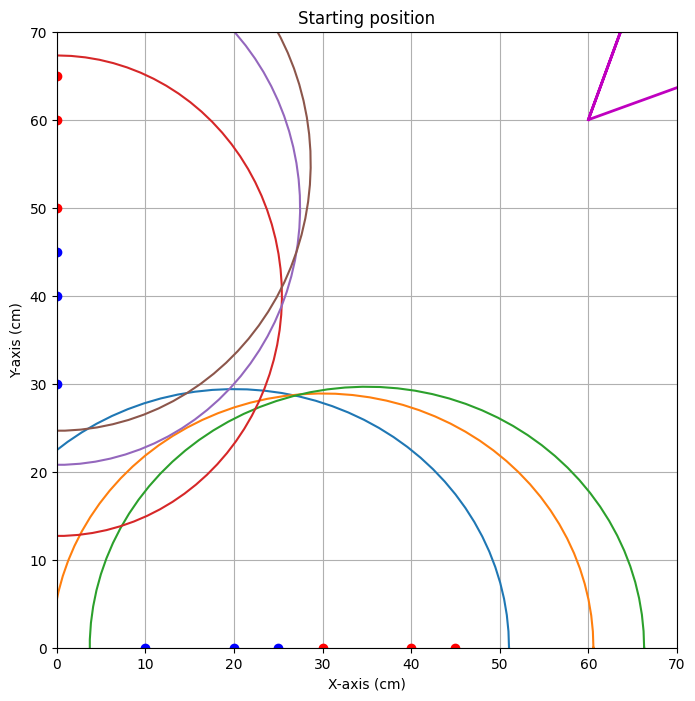


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=76.889


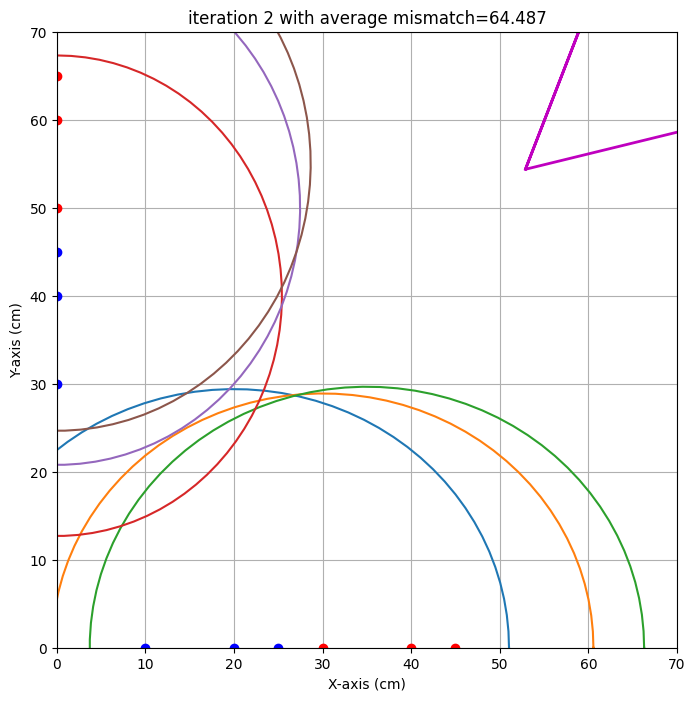

end iteration 2 with average mismatch=64.487


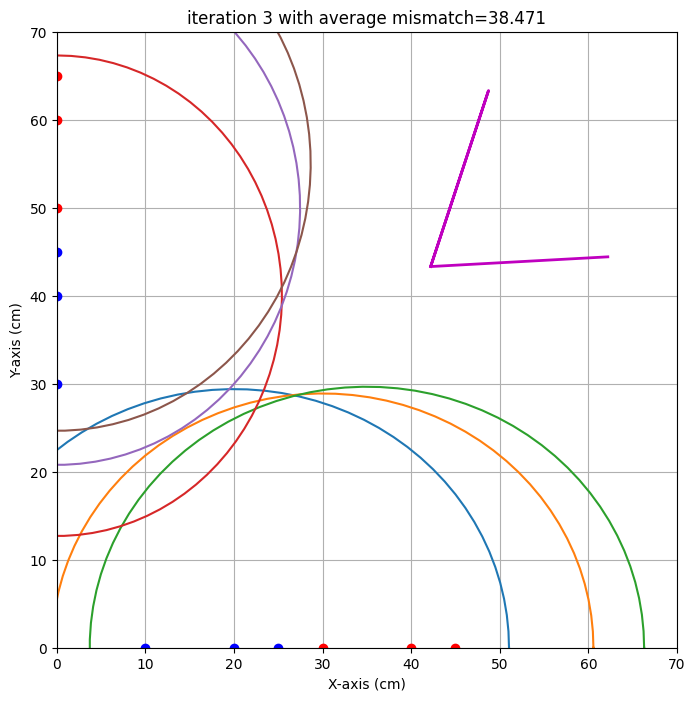

end iteration 3 with average mismatch=38.471


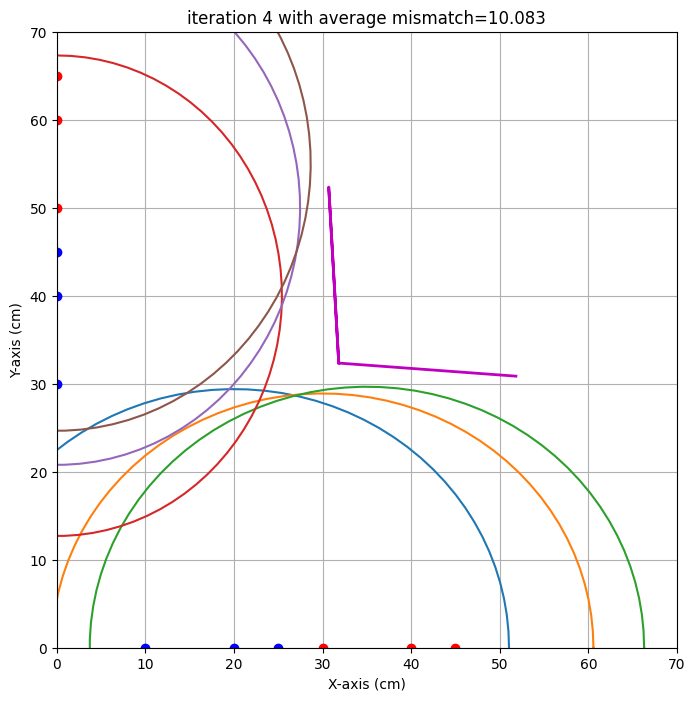

end iteration 4 with average mismatch=10.083


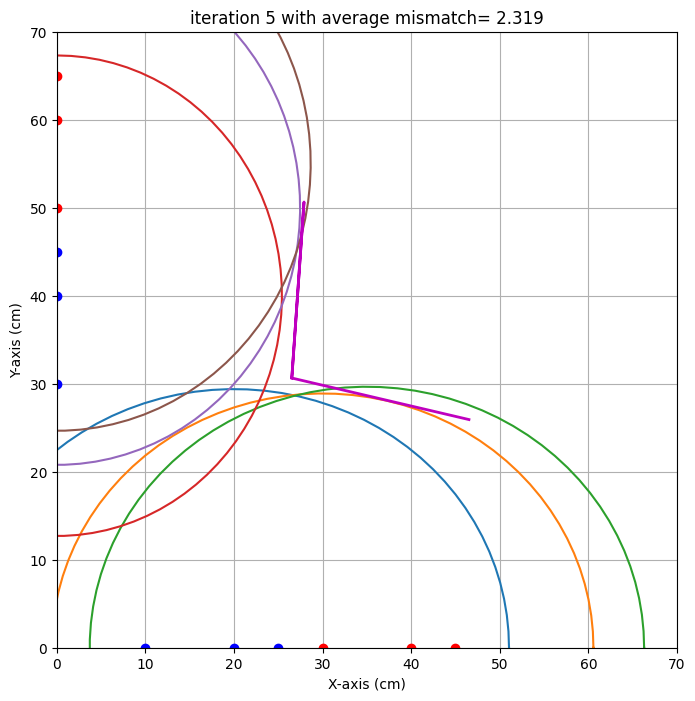

end iteration 5 with average mismatch= 2.319


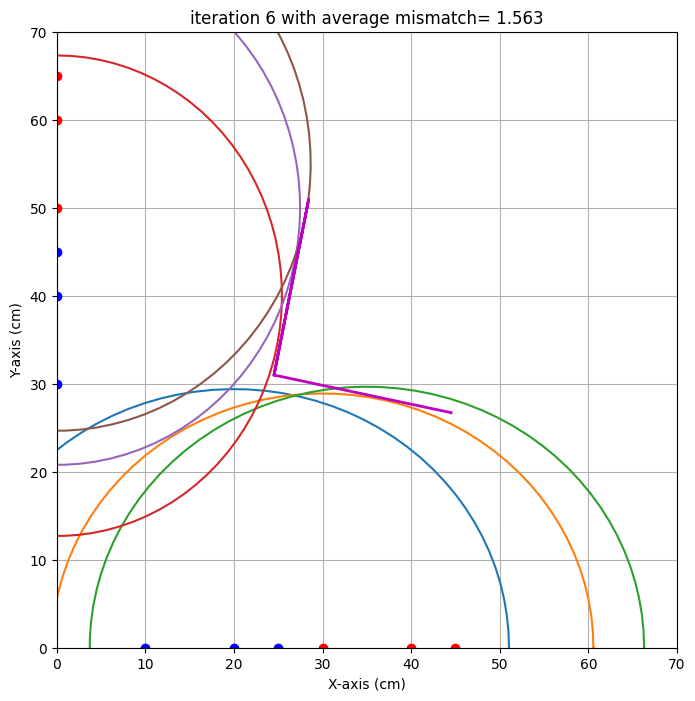

end iteration 6 with average mismatch= 1.563


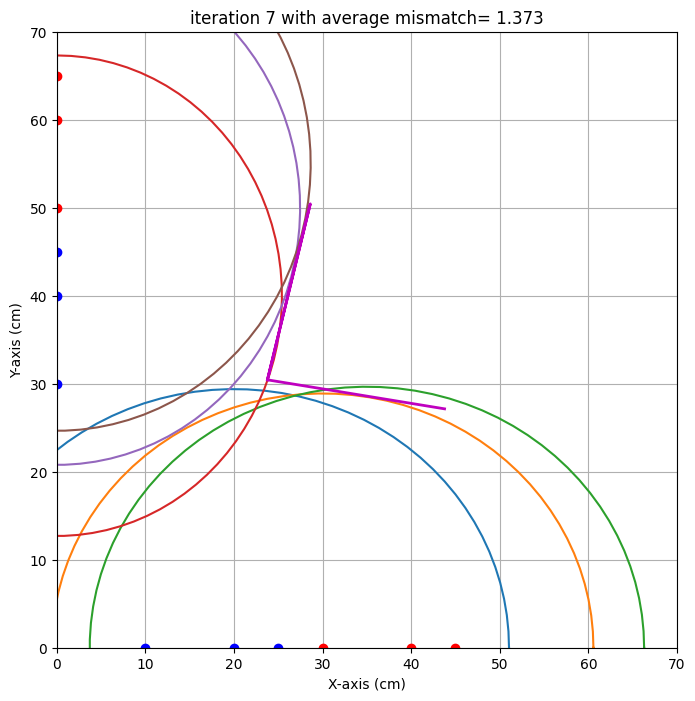

end iteration 7 with average mismatch= 1.373
end iteration 8 with average mismatch= 1.363


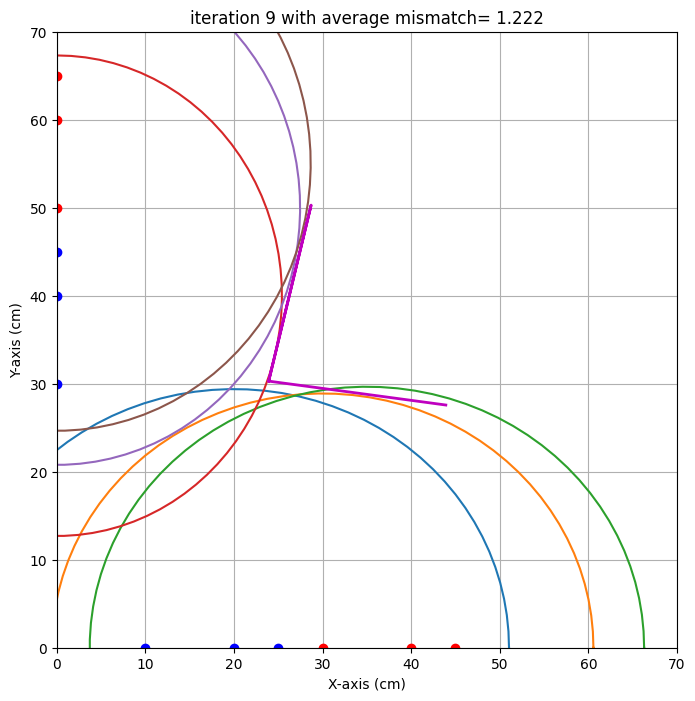

end iteration 9 with average mismatch= 1.222
end iteration 10 with average mismatch= 1.212
end iteration 11 with average mismatch= 1.128
end iteration 12 with average mismatch= 1.113
end iteration 13 with average mismatch= 1.106
end iteration 14 with average mismatch= 1.105
end iteration 15 with average mismatch= 1.074
end iteration 16 with average mismatch= 1.070
end iteration 17 with average mismatch= 1.070
end iteration 18 with average mismatch= 1.070
end iteration 19 with average mismatch= 1.070
end iteration 20 with average mismatch= 1.070
end iteration 21 with average mismatch= 1.070
end iteration 22 with average mismatch= 1.070
end iteration 23 with average mismatch= 1.070
end iteration 24 with average mismatch= 1.070
end iteration 25 with average mismatch= 1.070
end iteration 26 with average mismatch= 1.070
end iteration 27 with average mismatch= 1.070
end iteration 28 with average mismatch= 1.070
end iteration 29 with average mismatch= 1.070
Last iteration, also determine unce

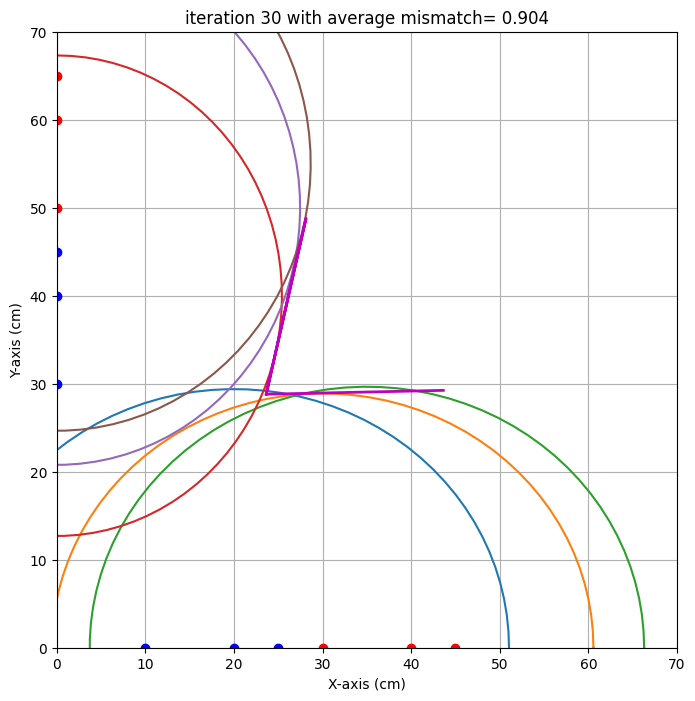

end iteration 30 with average mismatch= 0.904
###############################################################################
end of iteration  30
Best alpha=   1.26 with uncertainty=   0.00
Best beta =  12.68 with uncertainty=   0.00
Best x0   =  23.63 with uncertainty=   0.00
Best y0   =  28.81 with uncertainty=   0.00
###############################################################################


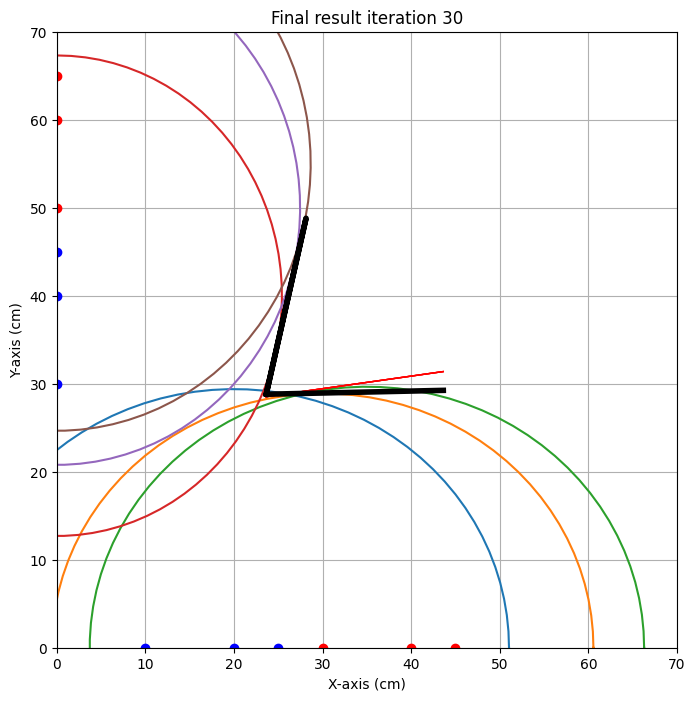

{'alpha': np.float64(1.2614723469578384), 'alpha_eps': 0.0, 'beta': np.float64(12.682435807096201), 'beta_eps': 0.0, 'x0': np.float64(23.62731590141924), 'x0_eps': 0.0, 'y0': np.float64(28.805111555828898), 'y0_eps': 0.0}
locatie 1 
x0 target is : 31.0. Gevonden waarde: 35.2 cm met een standaardafwijking van 0.3 cm 
y0 target is : 45.5. Gevonden waarde: 47.7 cm met een standaardafwijking van 0.8 cm 
alpha target is : 15.0. Gevonden waarde: 6.7 graden met een standaardafwijking van 4.2 graad 
beta target is : -20.0. Gevonden waarde: -14.0 graden met een standaardafwijking van 5.0 graad 

locatie 2 
x0 target is : 22.0. Gevonden waarde: 23.6 cm met een standaardafwijking van 0.0 cm 
y0 target is : 25.5. Gevonden waarde: 28.8 cm met een standaardafwijking van 0.0 cm 
alpha target is : 3.0. Gevonden waarde: 1.3 graden met een standaardafwijking van 0.0 graad 
beta target is : 27.0. Gevonden waarde: 12.7 graden met een standaardafwijking van 0.0 graad 



In [25]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0':31,#zelf aanvullen,
                    'y0':45.5,#zelf aanvullen,
                    'alpha':15, #zelf aanvullen,
                    'beta':-20 #zelf aanvullen},
            },
           'locatie 2':{'x0':22,#zelf aanvullen,
                    'y0':25.5,#zelf aanvullen,
                    'alpha':3,#zelf aanvullen,
                    'beta':27#zelf aanvullen}
            }}
           
Meting1 = np.array([98.10,98.62,101.27,74.68,68.28,67.41])
Meting2 = np.array([62.09,61.15,62.60,54.61,58.45,60.70])
# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
        #[0,30,0,10,Meting1[0]], # fout
        [50,0,30,0,Meting1[0]],
        [60,0,40,0,Meting1[1]],
        [65,0,45,0,Meting1[2]],
        #[30,0,10,0,Meting1[0]], # fout
        [0,50,0,30,Meting1[3]],
        [0,60,0,40,Meting1[4]],
        [0,65,0,45,Meting1[5]]
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
        [30,0,10,0,Meting2[0]],
        [40,0,20,0,Meting2[1]],
        #[25,0,5,0,Meting2[2]], # fout
        [45,0,25,0,Meting2[2]],
        #[0,30,0,10,Meting2[3]], # fout
        [0,50,0,30,Meting2[3]],
        [0,60,0,40,Meting2[4]],
        [0,65,0,45,Meting2[5]]
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

In [ ]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0':  # zelf aanvullen,
                    'y0':  # zelf aanvullen,
                    'alpha' :  # zelf aanvullen,
                    'beta' :  # zelf aanvullen
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    # zelf aanvullen
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.
Figuur: ![Alt](tudelftLogo.png "Title")

Figuur: ![Alt](tudelftLogo.png "Title")

Figuur: ![Alt](tudelftLogo.png "Title")